In [100]:
import warnings
warnings.filterwarnings("ignore")

In [101]:
import matplotlib.pyplot as plt
import numpy             as np
import pandas            as pd

from IPython import display
from tqdm import tqdm
import json
import time

from   torch.utils.data    import DataLoader, TensorDataset
import torch.nn.functional as F
import torch.nn            as nn
import os
import torch

default_path  = os.getcwd()
print(default_path)

torch.manual_seed(seed = 42)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

/home/drew/Split-Learning/Replicating Mullenbach
cuda


In [102]:
def time_it(func):
    def wrapper(*arg, **kw):
        t1 = time.time()
        res = func(*arg, **kw)
        t2 = time.time()
        secs = (t2 - t1)
        print(f'Runtime: {secs:.3f}s')
        return res
    return wrapper

### Load in our dataset from PreProcessing.ipynb

In [103]:
train_50_path = os.path.join(default_path,'train_50.csv')
train_df      = pd.read_csv(train_50_path)
X_train, Y_train = train_df['TEXT'],train_df['LABEL']

X_train = X_train.apply(func = json.loads).to_list()
Y_train = Y_train.apply(func = json.loads).to_list()
X_train = np.array(X_train)
Y_train = np.array(Y_train)

test_50_path = os.path.join(default_path,'test_50.csv')
test_df      = pd.read_csv(test_50_path)
X_test, Y_test = train_df['TEXT'],train_df['LABEL']

X_test = X_test.apply(func = json.loads).to_list()
Y_test = Y_test.apply(func = json.loads).to_list()
X_test = np.array(X_test)
Y_test = np.array(Y_test)

### Convvert to DataLoader (Pytorch)

In [104]:
X_train = torch.from_numpy(X_train).long()
Y_train = torch.from_numpy(Y_train).type(torch.float32)

X_test  = torch.from_numpy(X_test) .long()
Y_test  = torch.from_numpy(Y_test) .type(torch.float32)

train_loader = DataLoader(TensorDataset(X_train,Y_train) , batch_size = 64, shuffle = False)
test_loader  = DataLoader(TensorDataset(X_test ,Y_test ) , batch_size = 64 , shuffle = False)

In [105]:
vocab_size = max([torch.max(X_train),torch.max(X_test)]).item()
vocab_size

# To Save Memory, Delete all other variables not used
del train_df,test_df, X_train, Y_train

In [106]:
from model   import ConvAttnPool
from metrics import eval_model

In [107]:
model = ConvAttnPool(
            drop_out       = 0.2,
            num_of_words   = vocab_size + 1, # + 1. The size of our vocabulary is 13748
            num_of_filters = 50,
            label_space    = 50, 
            kernel_size    = 5,
            embed_d        = 100)
model.to(device=device)

ConvAttnPool(
  (embed): Embedding(66421, 100, padding_idx=0)
  (conv): Conv1d(100, 50, kernel_size=(5,), stride=(1,), padding=(2,))
  (U): Linear(in_features=50, out_features=50, bias=True)
  (final): Linear(in_features=50, out_features=50, bias=True)
  (embed_drop): Dropout(p=0.2, inplace=False)
)

In [108]:
eval_model(model        = model,
           device       = device,
           label_space  = 50,
           data_loader  = train_loader)

eval_model(model        = model,
           device       = device,
           label_space  = 50,
           data_loader  = test_loader)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       149
           1       0.00      0.00      0.00       210
           2       0.00      0.00      0.00       340
           3       0.00      0.00      0.00       155
           4       0.00      0.00      0.00       548
           5       0.00      0.00      0.00       155
           6       0.00      0.00      0.00       195
           7       0.13      0.05      0.08       203
           8       0.00      0.00      0.00       247
           9       0.00      0.00      0.00       138
          10       0.00      0.00      0.00       181
          11       0.00      0.00      0.00       196
          12       0.00      0.00      0.00       127
          13       0.00      0.00      0.00       135
          14       0.07      0.76      0.12       100
          15       0.00      0.00      0.00        60
          16       0.00      0.00      0.00       148
          17       0.26    

In [109]:
@time_it
def train_model(model,device, optimizer ,data_loader, loss_module, num_epochs=100):
    best_model = None
    best_loss  = 1

    model.train()
    train_losses  = []
    epoch_losses  = []
    for epoch in (range(num_epochs)):
        epoch_loss = 0.0
        for data_inputs, data_labels in data_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.type(torch.float32).to(device)

            preds, alpha = model(data_inputs)
            preds = preds.type(torch.float32).to(device)
            
            loss  = loss_module(preds, data_labels)
            # Save the model
            if best_loss > loss.item():
                best_loss  = loss.item()
                best_model = model.state_dict()
                
            epoch_loss += loss.item()
            train_losses.append(loss.item())

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()
        # Plot the average loss per epoch
        epoch_loss /= len(data_loader)
        epoch_losses.append(epoch_loss)
        if epoch % 2 == 0:
            plt.scatter(y = epoch_losses,
                        x = [_ for _ in range(len(epoch_losses))],
                        alpha = 1, lw = 0.1, c = 'b', s = 14,label = 'train_loss')
            plt.show()
            display.clear_output(wait=True)
    return train_losses, best_model, best_loss

In [110]:
loss_module = torch.nn.BCEWithLogitsLoss()
#optimizer  = torch.optim.SGD(model.parameters(), lr = 0.1, momentum = 0.9)
optimizer   = torch.optim.Adam(model.parameters(), lr=0.01, betas =  (0.9,0.99)) #(0.1,0.3)

# saved_param = torch.load(f = '/home/drew/Split-Learning/ScratchWork/model.tar')
# model.load_state_dict(saved_param)

hist, best_model, best_loss  \
                    = train_model(
                   model       = model,
                   device      = device,
                   optimizer   = optimizer,
                   data_loader = train_loader,
                   loss_module = loss_module,
                   num_epochs  = 100)
print(f'Lowest Loss: {best_loss}')

Runtime: 37.578s
Lowest Loss: 2.2242827981244773e-05


In [111]:
model.load_state_dict(best_model)
print(f'Lowest Loss: {best_loss}')

Lowest Loss: 2.2242827981244773e-05


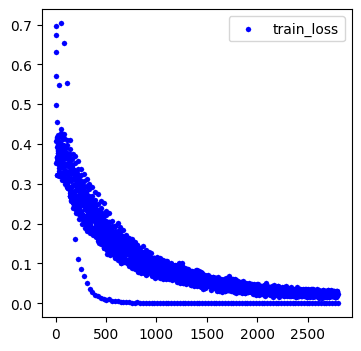

In [112]:
plt.figure(figsize=(4,4))
plt.scatter(y = hist,
            x = [_ for _ in range(len(hist))],
            alpha = 1, lw = 0.1, c = 'b', s = 14,label = 'train_loss')
plt.legend()
plt.show()

In [113]:
from sklearn.metrics import classification_report

@torch.no_grad()
def eval_model(model, device, data_loader,label_space):
    model.eval()
    all_pred   = torch.empty((0,), dtype = torch.float32).to(device)
    all_labels = torch.empty((0,), dtype = torch.float32).to(device)

    for data_inputs, data_labels in data_loader:
        data_inputs = data_inputs.to(device)
        data_labels = data_labels.to(device)
        preds, _ = model(data_inputs)
        #pred_labels = F.one_hot(preds.argmax(dim = 1),num_classes=label_space)
        pred_labels = (F.sigmoid(preds) >= 0.5).long()

        all_pred   = torch.cat((all_pred,pred_labels), dim = 0 )
        all_labels = torch.cat((all_labels,data_labels))
    print(classification_report(y_pred =   all_pred.cpu().numpy(), y_true = all_labels.cpu().numpy(), zero_division = 0))

In [114]:
eval_model(model        = model,
           device       = device,
           label_space  = 50,
           data_loader  = train_loader)

eval_model(model        = model,
           device       = device,
           label_space  = 50,
           data_loader  = test_loader)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       149
           1       0.88      0.99      0.93       210
           2       0.99      1.00      1.00       340
           3       0.99      1.00      0.99       155
           4       1.00      1.00      1.00       548
           5       1.00      0.99      0.99       155
           6       0.99      1.00      0.99       195
           7       1.00      1.00      1.00       203
           8       0.99      1.00      0.99       247
           9       1.00      0.99      1.00       138
          10       0.99      1.00      1.00       181
          11       0.98      1.00      0.99       196
          12       1.00      1.00      1.00       127
          13       1.00      1.00      1.00       135
          14       1.00      1.00      1.00       100
          15       1.00      1.00      1.00        60
          16       0.99      1.00      0.99       148
          17       0.99    

In [115]:
model_path = os.path.join(default_path,'model.tar')

In [ ]:
#torch.save(model.state_dict(),f = model_path)